### Activations analysis

In [ ]:
# data
n = 2000
d = 20
test_frac = 0.2

# DGP
n_classes = 2
n_informative = 10

# regression
X, y = make_regression(
    n_samples=n, n_features=d, n_informative=n_informative, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=test_frac, random_state=42)
regressor = TabPFNRegressor(
    device='cuda', n_estimators=12)  # , n_enc_layers=5)
regressor.fit(X_train, y_train)
y_test_tabpfn = regressor.predict(X_test)
print('r2 test', r2_score(y_test, y_test_tabpfn))

# classification
# X, y = make_classification(
#     n_samples=n, n_features=d, n_informative=n_informative, random_state=42)
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=test_frac, random_state=42)
# classifier = TabPFNClassifier(device='cuda', n_estimators=1)
# classifier.fit(X_train, y_train)
# y_test_tabpfn = classifier.predict(X_test)
# print('acc test', accuracy_score(y_test, y_test_tabpfn))

r2 test -0.024403099428347508


In [12]:
# model = classifier
model = regressor
m = model.model_
activations = {}


def get_activation(name):
    def hook(model, input, output):
        activations[name] = output.detach()
    return hook


# Register hooks on specific layers (example: Transformer blocks)
for idx, block in enumerate(m.transformer_encoder.layers):
    block.self_attn_between_features.register_forward_hook(
        get_activation(f'enc_attn_f_{idx}'))
for idx, block in enumerate(m.transformer_encoder.layers):
    block.self_attn_between_items.register_forward_hook(
        get_activation(f'enc_attn_i_{idx}'))
for idx, block in enumerate(m.transformer_encoder.layers):
    block.register_forward_hook(get_activation(f'enc_{idx}'))
for idx, block in enumerate(m.decoder_dict.standard):
    block.register_forward_hook(get_activation(f'dec_{idx}'))

# Fit model (for inference)
# preds = model.predict_proba(X_test)
preds = model.predict(X_test, output_type='mode')
print('initial inputs.shape', X_test.shape)
print('final preds.shape', preds.shape)

# Display extracted activations

print('enc sizes are batch_size, num_samples (train + test), n_heads, d_output?')
# note: half the heads are training heads, whereas the other half are inference heads which do not attend to each other
print(
    'dec sizes are (num_samples [test], 1, 10 classes [actual values are the first n_classes, rest are dropped])')
# note: regression basically does 5000-class classification over quantiles then averages them
# (classification is easier to study)
for layer, activation in activations.items():
    print(f"{layer}: {activation.shape}")

[transformer LayerStack] x torch.Size([1, 2000, 12, 192])
[transformer LayerStack] x torch.Size([1, 2000, 12, 192])
[transformer LayerStack] x torch.Size([1, 2000, 12, 192])
[transformer] encoder_out torch.Size([1, 2000, 12, 192])
initial inputs.shape (400, 20)
final preds.shape (400,)
enc sizes are batch_size, num_samples (train + test), n_heads, d_output?
dec sizes are (num_samples [test], 1, 10 classes [actual values are the first n_classes, rest are dropped])
enc_attn_f_0: torch.Size([1, 2000, 12, 192])
enc_attn_i_0: torch.Size([1, 12, 1600, 192])
enc_0: torch.Size([1, 2000, 12, 192])
enc_attn_f_1: torch.Size([1, 2000, 12, 192])
enc_attn_i_1: torch.Size([1, 12, 1600, 192])
enc_1: torch.Size([1, 2000, 12, 192])
enc_attn_f_2: torch.Size([1, 2000, 12, 192])
enc_attn_i_2: torch.Size([1, 12, 1600, 192])
enc_2: torch.Size([1, 2000, 12, 192])
dec_0: torch.Size([400, 1, 768])
dec_1: torch.Size([400, 1, 768])
dec_2: torch.Size([400, 1, 5000])


In [ ]:
d = vars(m.transformer_encoder.layers[0].self_attn_between_features)
# only show elements with scalar values
for k, v in d.items():
    if np.isscalar(v):
        print(k, v)

### increasing tree depth experiment

In [ ]:
from collections import defaultdict
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
import torch
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, r2_score, mean_squared_error  # added

from tabpfn_extensions import TabPFNRegressor, TabPFNClassifier  # v2.5

from interpret.glassbox import ExplainableBoostingClassifier

device_to_use = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device_to_use}")


# data
n = 10000
d = 15
test_frac = 0.3

# DGP
n_classes = 2
n_informative = 10

r = defaultdict(list)
# depths = [10]
depths = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
r['depth'] = depths

for depth in tqdm(depths):
    X, y = make_classification(
        n_samples=n,
        n_features=d,
        n_informative=n_informative,
        n_classes=n_classes,
        random_state=42
    )
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=test_frac, random_state=42
    )

    # teacher
    tree = DecisionTreeClassifier(max_depth=depth, random_state=42)
    tree.fit(X_train, y_train)
    y_train_tree = tree.predict(X_train)
    y_test_tree = tree.predict(X_test)

    # ===== TabPFN =====
    tabpfn = TabPFNClassifier()
    tabpfn.fit(X_train, y_train_tree)

    y_test_tabpfn = tabpfn.predict(X_test)
    y_test_tabpfn_proba = tabpfn.predict_proba(X_test)[:, 1]

    acc_tabpfn = accuracy_score(y_test_tree, y_test_tabpfn)
    r2_tabpfn = r2_score(y_test_tree, y_test_tabpfn_proba)
    mse_tabpfn = mean_squared_error(y_test_tree, y_test_tabpfn_proba)  # added
    rmse_tabpfn = mean_squared_error(y_test_tree, y_test_tabpfn_proba)  # added

    # ===== EBM =====
    ebm = ExplainableBoostingClassifier(
        interactions= n_informative,
        outer_bags=4,
        max_bins=256,
        random_state=42
    )
    ebm.fit(X_train, y_train_tree)

    y_test_ebm = ebm.predict(X_test)
    y_test_ebm_proba = ebm.predict_proba(X_test)[:, 1]

    acc_ebm = accuracy_score(y_test_tree, y_test_ebm)
    r2_ebm = r2_score(y_test_tree, y_test_ebm_proba)
    mse_ebm = mean_squared_error(y_test_tree, y_test_ebm_proba)  # added
    rmse_ebm = mean_squared_error(y_test_tree, y_test_ebm_proba)  # added

    r['acc_tabpfn'].append(acc_tabpfn)
    r['acc_ebm'].append(acc_ebm)
    r['r2_tabpfn'].append(r2_tabpfn)
    r['r2_ebm'].append(r2_ebm)
    r['mse_tabpfn'].append(mse_tabpfn)    # added
    r['mse_ebm'].append(mse_ebm)          # added
    r['rmse_tabpfn'].append(rmse_tabpfn)  # added
    r['rmse_ebm'].append(rmse_ebm)        # added

    print(
        f"depth={depth:2d} | "
        f"tabpfn acc={acc_tabpfn:.4f}, r2={r2_tabpfn:.4f}, mse={mse_tabpfn:.4f}, rmse={rmse_tabpfn:.4f} \n "
        f"ebm acc={acc_ebm:.4f}, r2={r2_ebm:.4f}, mse={mse_ebm:.4f}, rmse={rmse_ebm:.4f}"
    )

r = pd.DataFrame(r)


Using device: cuda


 10%|█         | 1/10 [00:08<01:18,  8.78s/it]

depth= 1 | tabpfn acc=0.9987, r2=0.9971, mse=0.0006, rmse=0.0006 
 ebm acc=0.9987, r2=0.9941, mse=0.0013, rmse=0.0013


 20%|██        | 2/10 [03:32<16:27, 123.44s/it]

depth= 2 | tabpfn acc=0.9993, r2=0.9961, mse=0.0008, rmse=0.0008 
 ebm acc=0.9977, r2=0.9893, mse=0.0022, rmse=0.0022


...

depth= 8 | tabpfn acc=0.9003, r2=0.7084, mse=0.0729, rmse=0.0729 
 ebm acc=0.8910, r2=0.6771, mse=0.0807, rmse=0.0807


 90%|█████████ | 9/10 [05:20<00:18, 18.86s/it]

depth= 9 | tabpfn acc=0.8890, r2=0.6481, mse=0.0880, rmse=0.0880 
 ebm acc=0.8743, r2=0.6298, mse=0.0925, rmse=0.0925


100%|██████████| 10/10 [05:33<00:00, 33.32s/it]

depth=10 | tabpfn acc=0.8883, r2=0.6390, mse=0.0902, rmse=0.0902 
 ebm acc=0.8757, r2=0.6337, mse=0.0915, rmse=0.0915


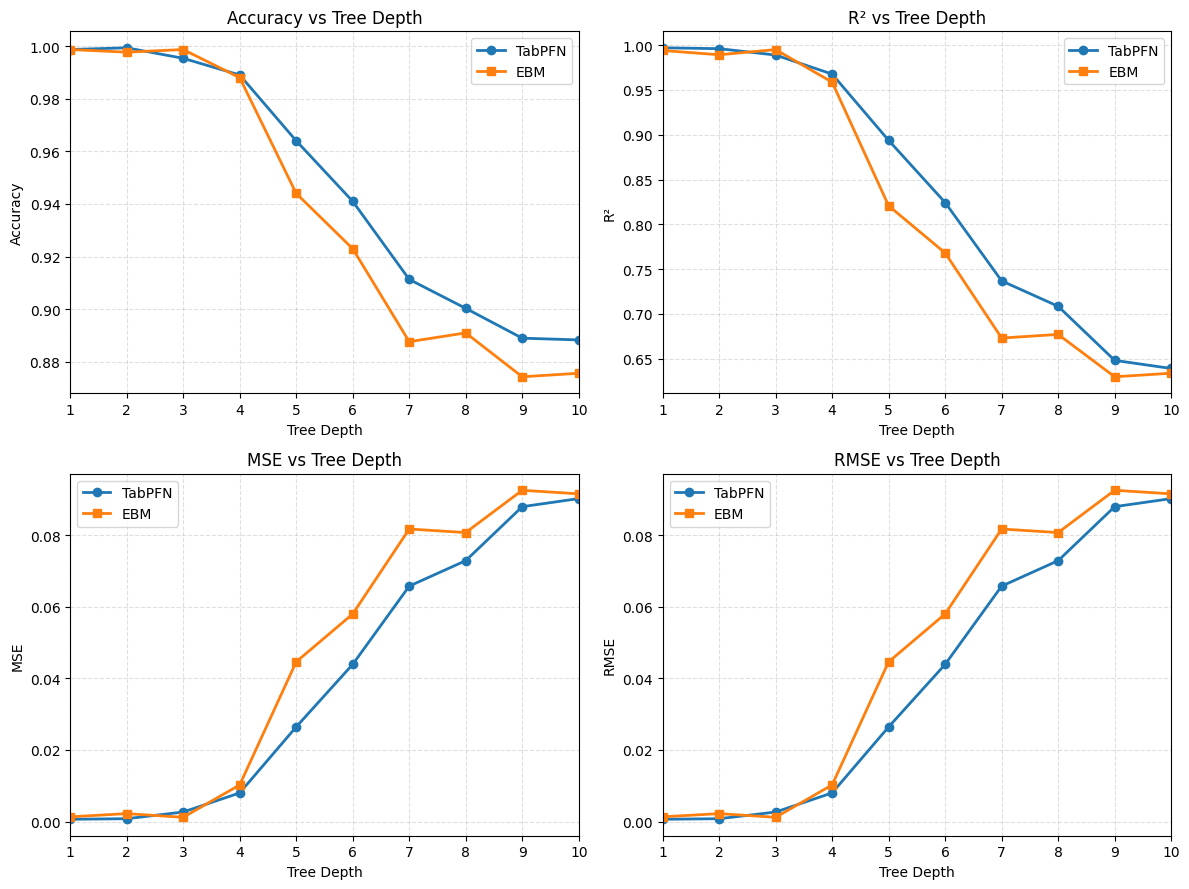

In [43]:
import matplotlib.pyplot as plt

# Metrics to plot: (column suffix, y-axis label, title)
metrics = [
    ("acc", "Accuracy", "Accuracy vs Tree Depth"),
    ("r2", "R²", "R² vs Tree Depth"),
    ("mse", "MSE", "MSE vs Tree Depth"),
    ("rmse", "RMSE", "RMSE vs Tree Depth"),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()

for ax, (m, ylabel, title) in zip(axes, metrics):
    ax.plot(
        r["depth"],
        r[f"{m}_tabpfn"],
        marker="o",
        linewidth=2,
        label="TabPFN",
    )
    ax.plot(
        r["depth"],
        r[f"{m}_ebm"],
        marker="s",
        linewidth=2,
        label="EBM",
    )

    ax.set_xlabel("Tree Depth")
    ax.set_ylabel(ylabel)
    ax.set_title(title)

    ax.set_xticks(range(1, 11))
    ax.set_xlim(1, 10)

    ax.grid(True, linestyle="--", alpha=0.4)
    ax.legend()

plt.tight_layout()

# Save as PDF (vector graphics, paper-ready)
plt.savefig("tabpfn_vs_ebm_depth_metrics.pdf", format="pdf", bbox_inches="tight")

plt.show()


In [44]:
from collections import defaultdict
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
import torch
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, r2_score, mean_squared_error

from tabpfn_extensions import TabPFNClassifier  # v2.5
from interpret.glassbox import ExplainableBoostingClassifier

device_to_use = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device_to_use}")

# -------------------------
# Experiment setup
# -------------------------
n = 10000
d = 15
test_frac = 0.3
n_classes = 2
n_informative = 10

# depths = [10]
depths = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

seeds = list(range(30,50))  # 20 different random seeds

records = []

# -------------------------
# Main loop
# -------------------------
for depth in depths:
    for seed in tqdm(seeds, desc=f"depth={depth}"):

        X, y = make_classification(
            n_samples=n,
            n_features=d,
            n_informative=n_informative,
            n_classes=n_classes,
            random_state=seed
        )

        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=test_frac, random_state=seed
        )

        # ===== Teacher tree =====
        tree = DecisionTreeClassifier(max_depth=depth, random_state=seed)
        tree.fit(X_train, y_train)
        y_train_tree = tree.predict(X_train)
        y_test_tree = tree.predict(X_test)

        # ===== TabPFN =====
        tabpfn = TabPFNClassifier()
        tabpfn.fit(X_train, y_train_tree)

        y_tabpfn = tabpfn.predict(X_test)
        y_tabpfn_proba = tabpfn.predict_proba(X_test)[:, 1]

        # ===== EBM =====
        ebm = ExplainableBoostingClassifier(
            interactions=n_informative,
            outer_bags=4,
            max_bins=256,
            random_state=seed
        )
        ebm.fit(X_train, y_train_tree)

        y_ebm = ebm.predict(X_test)
        y_ebm_proba = ebm.predict_proba(X_test)[:, 1]

        # -------------------------
        # Metrics
        # -------------------------
        records.append({
            "depth": depth,
            "seed": seed,

            "acc_tabpfn": accuracy_score(y_test_tree, y_tabpfn),
            "r2_tabpfn": r2_score(y_test_tree, y_tabpfn_proba),
            "mse_tabpfn": mean_squared_error(y_test_tree, y_tabpfn_proba),
            "rmse_tabpfn": mean_squared_error(y_test_tree, y_tabpfn_proba) ** 0.5,

            "acc_ebm": accuracy_score(y_test_tree, y_ebm),
            "r2_ebm": r2_score(y_test_tree, y_ebm_proba),
            "mse_ebm": mean_squared_error(y_test_tree, y_ebm_proba),
            "rmse_ebm": mean_squared_error(y_test_tree, y_ebm_proba) ** 0.5,
        })

# -------------------------
# Aggregate: mean + 95% CI
# -------------------------
df = pd.DataFrame(records)

def mean_ci(x):
    mean = x.mean()
    ci = 1.96 * x.std(ddof=1) / np.sqrt(len(x))
    return pd.Series({"mean": mean, "ci": ci})

metric_cols = [c for c in df.columns if c not in ["depth", "seed"]]

# 1) scalar aggregations
agg = df.groupby("depth")[metric_cols].agg(["mean", "std", "count"])

# 2) compute 95% CI = 1.96 * std / sqrt(n)
ci = 1.96 * agg.xs("std", axis=1, level=1) / np.sqrt(agg.xs("count", axis=1, level=1))

# 3) final table: (mean, ci)
mean = agg.xs("mean", axis=1, level=1)
summary = pd.concat({"mean": mean, "ci": ci}, axis=1).swaplevel(0, 1, axis=1).sort_index(axis=1)

print("\nSummary (mean ± 95% CI):")
print(summary)


Using device: cuda


depth=10: 100%|██████████| 20/20 [05:06<00:00, 15.33s/it]


Summary (mean ± 95% CI):
        acc_ebm           acc_tabpfn             mse_ebm           mse_tabpfn  \
             ci      mean         ci      mean        ci      mean         ci   
depth                                                                           
1      0.000460  0.999117   0.000204  0.999517  0.000306  0.000633   0.000105   
2      0.000532  0.998250   0.000452  0.998633  0.000426  0.001408   0.000280   
3      0.002424  0.993983   0.000708  0.996100  0.001811  0.004522   0.000621   
4      0.006476  0.973950   0.002696  0.985383  0.004909  0.020804   0.001922   
5      0.008129  0.946283   0.004009  0.967917  0.005909  0.042004   0.002841   
6      0.009545  0.923400   0.005385  0.949200  0.006564  0.058073   0.003823   
7      0.008963  0.909000   0.005851  0.931500  0.006672  0.068924   0.004395   
8      0.009676  0.898700   0.006573  0.915750  0.006710  0.075848   0.004714   
9      0.009456  0.893117   0.007471  0.905450  0.006806  0.080877   0.005435   
10

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ---- Helper to pull mean/ci series from the multi-index summary ----
def get_mean_ci(summary_df, colname):
    mean = summary_df[("mean", colname)]
    ci = summary_df[("ci", colname)]
    return mean, ci

# Ensure depths are sorted and are the x-axis
x = summary.index.to_numpy()

metrics = [
    ("acc", "Accuracy", "Accuracy vs Tree Depth"),
    ("r2", "R²", "R² vs Tree Depth"),
    ("mse", "MSE", "MSE vs Tree Depth"),
    ("rmse", "RMSE", "RMSE vs Tree Depth"),
]

fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()

for ax, (m, ylabel, title) in zip(axes, metrics):
    # TabPFN
    tab_mean, tab_ci = get_mean_ci(summary, f"{m}_tabpfn")
    ax.plot(x, tab_mean.to_numpy(), marker="o", linewidth=2, label="TabPFN")
    ax.fill_between(
        x,
        (tab_mean - tab_ci).to_numpy(),
        (tab_mean + tab_ci).to_numpy(),
        alpha=0.2,
    )

    # EBM
    ebm_mean, ebm_ci = get_mean_ci(summary, f"{m}_ebm")
    ax.plot(x, ebm_mean.to_numpy(), marker="s", linewidth=2, label="EBM")
    ax.fill_between(
        x,
        (ebm_mean - ebm_ci).to_numpy(),
        (ebm_mean + ebm_ci).to_numpy(),
        alpha=0.2,
    )

    ax.set_xlabel("Tree Depth")
    ax.set_ylabel(ylabel)
    ax.set_title(title)

    # Force x-axis ticks from 1 to 10
    ax.set_xticks(range(1, 11))
    ax.set_xlim(1, 10)

    ax.grid(True, linestyle="--", alpha=0.4)
    ax.legend()

plt.tight_layout()

# Save as vector PDF (paper-ready)
plt.savefig("tabpfn_vs_ebm_depth_metrics_ci.pdf", format="pdf", bbox_inches="tight")

plt.show()
